In [1]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import gc

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, recall_score, precision_score, f1_score,\
    confusion_matrix, ConfusionMatrixDisplay, average_precision_score

from catboost import CatBoostClassifier
from catboost import utils

Загрузим полный набор данных

In [2]:
train_part1 = pl.read_parquet("../ClearData/train_full.parquet")
train_part1.shape

(85677840, 14)

In [3]:
train_part1.schema

Schema([('event_type_nm', Int16),
        ('event_desc', Int32),
        ('channel_indicator_type', Int16),
        ('channel_indicator_sub_type', Int16),
        ('operaton_amt', Float64),
        ('currency_iso_cd', Int16),
        ('mcc_code', Int16),
        ('pos_cd', Int16),
        ('developer_tools', Int32),
        ('phone_voip_call_state', Int32),
        ('web_rdp_connection', Int16),
        ('compromised', Int16),
        ('Hour', Int16),
        ('target', Int16)])

In [4]:
train_part1["target"].value_counts()

target,count
i16,u32
1,51438
0,85626402


In [5]:
x = train_part1.drop("target")
y = train_part1["target"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.05, stratify=y)   

In [7]:
del train_part1, x, y
gc.collect()

0

In [8]:
def train_models(model, X_train, X_test, y_train, y_test, sample_weight=None):      # This function training model and output accuracy metrics
    if (sample_weight is None):
        model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train, sample_weight=sample_weight)
        
    predict_train = model.predict(X_train)
    print(f"Train metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_train, y_pred=predict_train)}")
    print(f"Precision: {precision_score(y_true=y_train, y_pred=predict_train)}")
    print(f"Recall: {recall_score(y_true=y_train, y_pred=predict_train)}")
    print(f"F1-score: {f1_score(y_true=y_train, y_pred=predict_train)}")
    y_pred_proba = model.predict_proba(X_train)[:, 1]
    print(f"PR-AUC: {average_precision_score(y_true=y_train, y_score=y_pred_proba)}\n")

    predict_test = model.predict(X_test)
    print(f"Test metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Precision: {precision_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Recall: {recall_score(y_true=y_test, y_pred=predict_test)}")
    print(f"F1-score: {f1_score(y_true=y_test, y_pred=predict_test)}")
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    print(f"PR-AUC: {average_precision_score(y_true=y_test, y_score=y_pred_proba)}\n")

    print("Confusion matrix")
    cm = confusion_matrix(y_true=y_test, y_pred=predict_test, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)    
    disp.plot()

In [ ]:
CatBoost = CatBoostClassifier(iterations=5, depth=2, auto_class_weights='Balanced', verbose=False)

: 

In [ ]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [ ]:
CatBoost = CatBoostClassifier(iterations=15, depth=3, auto_class_weights='Balanced', verbose=False)

Train metrics:
Accuracy: 0.8563051122863636
Precision: 0.002164265334445319
Recall: 0.5120158506966637
F1-score: 0.004310311199518553
PR-AUC: 0.0038093987565896463

Test metrics:
Accuracy: 0.8563654406574746
Precision: 0.0021358373066069866
Recall: 0.5051783659378596
F1-score: 0.004253690488302351
PR-AUC: 0.003837679978306029

Confusion matrix


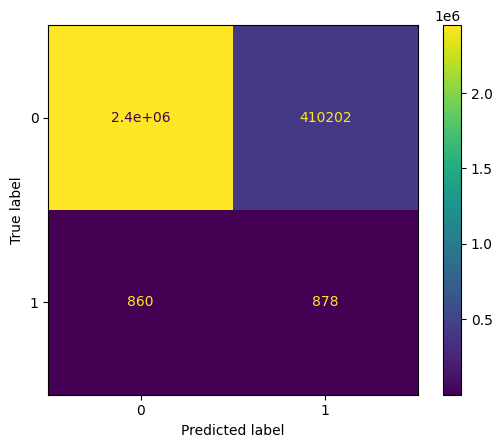

In [ ]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [ ]:
CatBoost = CatBoostClassifier(iterations=15, depth=4, auto_class_weights='Balanced', verbose=False)

Train metrics:
Accuracy: 0.843079871850212
Precision: 0.0020530813039985117
Recall: 0.5304870254378116
F1-score: 0.004090332277896189
PR-AUC: 0.004503824935931207

Test metrics:
Accuracy: 0.8430062966043063
Precision: 0.0020627044347032776
Recall: 0.5333716915995397
F1-score: 0.004109516167643434
PR-AUC: 0.004752966792323437

Confusion matrix


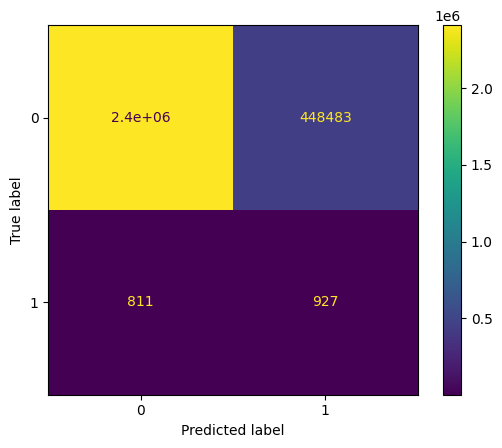

In [ ]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [ ]:
CatBoost = CatBoostClassifier(iterations=50, depth=4, auto_class_weights='Balanced', verbose=False)

Train metrics:
Accuracy: 0.7710110684064214
Precision: 0.0017025107671226518
Recall: 0.642272785376454
F1-score: 0.003396019502864515
PR-AUC: 0.006254522973525748

Test metrics:
Accuracy: 0.7712983863641129
Precision: 0.001717494320818779
Recall: 0.6472957422324511
F1-score: 0.003425898575130717
PR-AUC: 0.007056791170243742

Confusion matrix


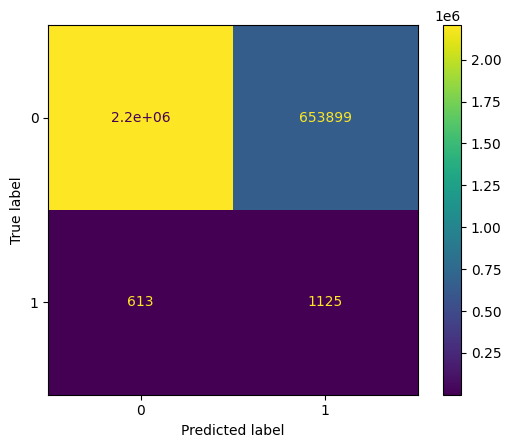

In [ ]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

Для моделей с auto_class_weights='Balanced' глубина 4 давала наилучшие результаты при числе итераций 15

Попробуем настроить веса меток самостоятельно

In [ ]:
weights = {0: 1, 1: 100}
CatBoost = CatBoostClassifier(iterations=15, depth=5, class_weights=weights, verbose=False)

Train metrics:
Accuracy: 0.9966493422652111
Precision: 0.017706484641638227
Recall: 0.08289658698708935
F1-score: 0.02918016558675306
PR-AUC: 0.00648742117904097

Test metrics:
Accuracy: 0.9966507795629416
Precision: 0.018056749785038694
Recall: 0.08457997698504027
F1-score: 0.02976009717582751
PR-AUC: 0.006586051222686831

Confusion matrix


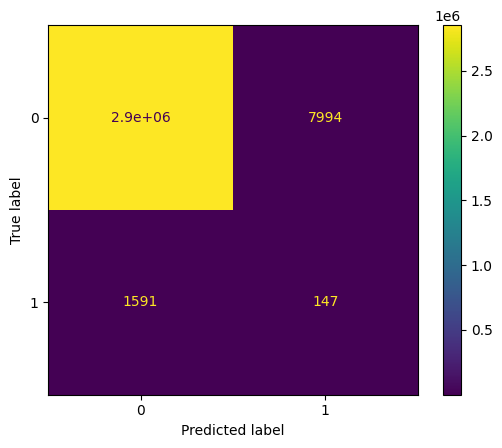

In [ ]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [ ]:
weights = {0: 1, 1: 100}
CatBoost = CatBoostClassifier(iterations=100, depth=5, class_weights=weights, verbose=False)

Train metrics:
Accuracy: 0.994490101112975
Precision: 0.01839887104771349
Recall: 0.15416080787421704
F1-score: 0.03287424782439809
PR-AUC: 0.00944768438942487

Test metrics:
Accuracy: 0.9945158044069242
Precision: 0.01789291882556131
Recall: 0.14902186421173763
F1-score: 0.03194967001788688
PR-AUC: 0.008975287194376154

Confusion matrix


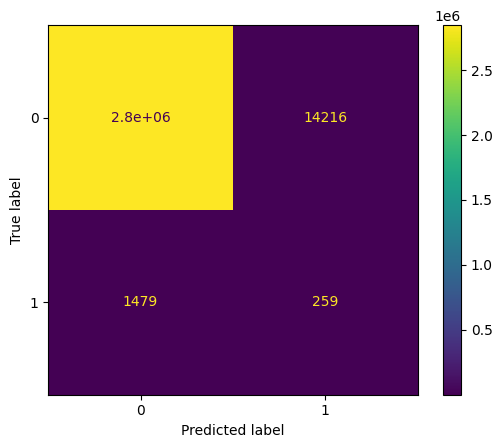

In [ ]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [ ]:
weights = {0: 1, 1: 1000}
CatBoost = CatBoostClassifier(iterations=100, depth=5, class_weights=weights, verbose=False)

Train metrics:
Accuracy: 0.9258979418741522
Precision: 0.003948015955581807
Recall: 0.48146491115940176
F1-score: 0.00783181100102771
PR-AUC: 0.008158203600138216

Test metrics:
Accuracy: 0.9261756340282195
Precision: 0.0037655060698063253
Recall: 0.4574223245109321
F1-score: 0.007469522937072793
PR-AUC: 0.009329235954715834

Confusion matrix


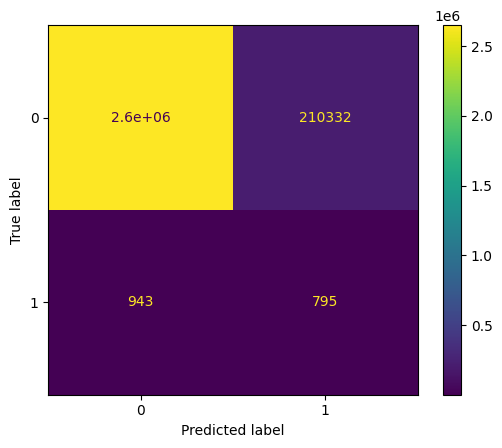

In [ ]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [ ]:
weights = {0: 1, 1: 1000}
CatBoost = CatBoostClassifier(iterations=200, depth=5, class_weights=weights, verbose=False)

Train metrics:
Accuracy: 0.928666693533427
Precision: 0.004196861661968105
Recall: 0.49277770676211174
F1-score: 0.008322839826353824
PR-AUC: 0.009344705010287988

Test metrics:
Accuracy: 0.928877024033321
Precision: 0.003830569815699927
Recall: 0.4482163406214039
F1-score: 0.007596220417158292
PR-AUC: 0.009426329284807761

Confusion matrix


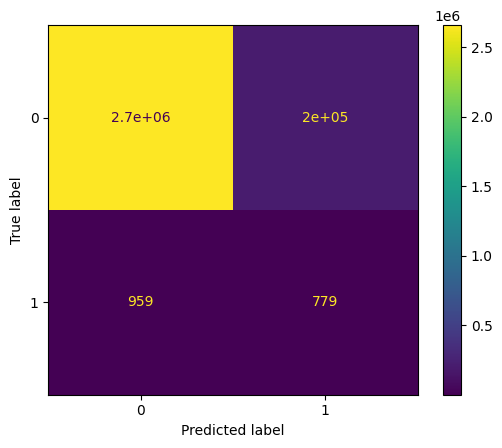

In [ ]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [ ]:
weights = {0: 1, 1: 1000}
CatBoost = CatBoostClassifier(iterations=20, depth=4, class_weights=weights, verbose=False)

Train metrics:
Accuracy: 0.9229970306017836
Precision: 0.0034035186012411765
Recall: 0.43097277259363415
F1-score: 0.006753701239614169
PR-AUC: 0.005293299028368935

Test metrics:
Accuracy: 0.9232796153550488
Precision: 0.0033788251173013173
Recall: 0.42635212888377444
F1-score: 0.0067045171797597775
PR-AUC: 0.005863021606714594

Confusion matrix


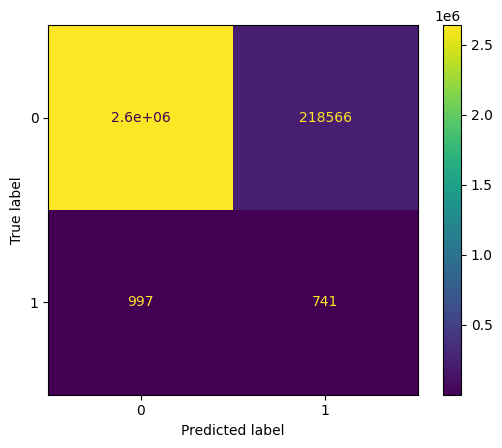

In [ ]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [ ]:
weights = {0: 1, 1: 800}
CatBoost = CatBoostClassifier(iterations=200, depth=4, class_weights=weights, verbose=False)

Train metrics:
Accuracy: 0.9394990063569395
Precision: 0.004648907612674519
Recall: 0.4626741659210022
F1-score: 0.009205321003620327
PR-AUC: 0.008815796843738982

Test metrics:
Accuracy: 0.9397164780946657
Precision: 0.004393525209084208
Recall: 0.43555811277330264
F1-score: 0.00869929957422847
PR-AUC: 0.009139332270600823

Confusion matrix


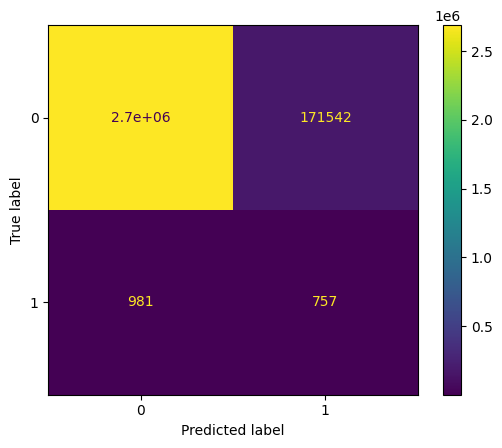

In [ ]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [ ]:
weights = {0: 1, 1: 500}
CatBoost = CatBoostClassifier(iterations=20, depth=4, class_weights=weights, verbose=False)

Train metrics:
Accuracy: 0.9618516074281778
Precision: 0.005479488485607265
Recall: 0.34238783075546464
F1-score: 0.010786354868457613
PR-AUC: 0.00546728922904383

Test metrics:
Accuracy: 0.9620596395351275
Precision: 0.0054710064430126635
Recall: 0.34004602991944766
F1-score: 0.010768754213662288
PR-AUC: 0.00594019591722384

Confusion matrix


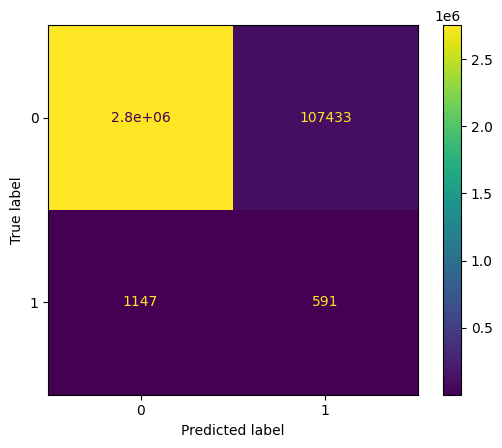

In [ ]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [ ]:
weights = {0: 1, 1: 500}
CatBoost = CatBoostClassifier(iterations=200, depth=4, class_weights=weights, verbose=False)

Train metrics:
Accuracy: 0.9616642001272366
Precision: 0.006446232468655119
Recall: 0.40559887511184967
F1-score: 0.012690768995407446
PR-AUC: 0.009349963513601631

Test metrics:
Accuracy: 0.9618838797145912
Precision: 0.0060737127870059355
Recall: 0.379746835443038
F1-score: 0.011956196842477106
PR-AUC: 0.009660006666512639

Confusion matrix


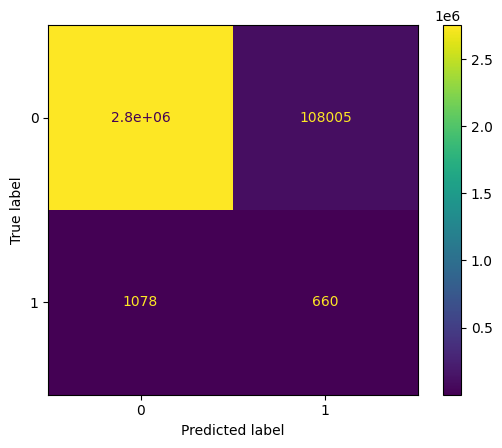

In [ ]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

Из последних показателей могу сделать вывод, что увеличение числа деревьев в ансамбле (после некоторого значения деревьев) сильного эффекта уже не дает, т.е. есть конкретный предел точночти, к которому при постоянном увеличении кол-ва деревьев модель стремится  

In [ ]:
weights = {0: 1, 1: 500}
CatBoost = CatBoostClassifier(iterations=200, depth=4, class_weights=weights, verbose=False)
train_models(CatBoost, x, X_test, y, y_test)

In [ ]:
CatBoost.save_model('Model_3.cbm')